In [ ]:
# Verificar que la base se cargó correctamente
print(base_final.shape)
base_final.head()

(606619, 144)


,CONGLOME,VIVIENDA,HOGAR,CODPERSO,UBIGEO,P207,P208A,ESTRATO,DOMINIO,AÑO,...,INGMO2HD,INGMO1HD,ES_POBRE,INGRESO_MENSUAL,INGRESO_PCAPITA,DEPARTAMENTO,PCT_GASTO_SALUD_HOGAR,GASTO_CATASTROFICO,UBIGEO_DPTO,IDH
0,10651,13,11,1,150509,1.0,74.0,4,2,2024,...,34042.000000,34042.000000,0,3811.344076,952.836019,15,4.082112,0,15,0.741497
1,10651,13,11,2,150509,2.0,70.0,4,2,2024,...,34042.000000,34042.000000,0,3811.344076,952.836019,15,0.000000,0,15,0.741497
2,10651,13,11,3,150509,2.0,22.0,4,2,2024,...,34042.000000,34042.000000,0,3811.344076,952.836019,15,0.000000,0,15,0.741497
3,10651,13,11,4,150509,1.0,19.0,4,2,2024,...,34042.000000,34042.000000,0,3811.344076,952.836019,15,0.000000,0,15,0.741497
4,10651,26,11,1,150509,1.0,48.0,4,2,2024,...,39221.332031,39221.332031,1,3413.194336,682.638867,15,0.000000,0,15,0.741497


In [ ]:
# Reconstruir una base de IDH por departamento y año a partir de la base final limpia.
# Esto permite elaborar los gráficos de la sección 5 sin volver a procesar
# el archivo original del IDH.

# Diccionario de nombres departamentales a partir del código de departamento
mapa_dptos = {
    "01": "AMAZONAS",
    "02": "ÁNCASH",
    "03": "APURÍMAC",
    "04": "AREQUIPA",
    "05": "AYACUCHO",
    "06": "CAJAMARCA",
    "07": "CALLAO",
    "08": "CUSCO",
    "09": "HUANCAVELICA",
    "10": "HUÁNUCO",
    "11": "ICA",
    "12": "JUNÍN",
    "13": "LA LIBERTAD",
    "14": "LAMBAYEQUE",
    "15": "LIMA",
    "16": "LORETO",
    "17": "MADRE DE DIOS",
    "18": "MOQUEGUA",
    "19": "PASCO",
    "20": "PIURA",
    "21": "PUNO",
    "22": "SAN MARTÍN",
    "23": "TACNA",
    "24": "TUMBES",
    "25": "UCAYALI"
}

# Seleccionar variables necesarias y eliminar duplicados
df_idh_aux = base_final[["COD_DPTO", "AÑO", "IDH"]].copy()

# Asegurar formatos correctos
df_idh_aux["COD_DPTO"] = df_idh_aux["COD_DPTO"].astype(str).str.zfill(2)
df_idh_aux["AÑO"] = pd.to_numeric(df_idh_aux["AÑO"], errors="coerce")
df_idh_aux["IDH"] = pd.to_numeric(df_idh_aux["IDH"], errors="coerce")

# Como el IDH es igual para todas las observaciones de un mismo departamento-año,
# nos quedamos con un solo valor por combinación
df_idh_aux = (
    df_idh_aux
    .dropna(subset=["COD_DPTO", "AÑO", "IDH"])
    .groupby(["COD_DPTO", "AÑO"], as_index=False)["IDH"]
    .mean()
)

# Pasar a formato ancho para replicar la estructura usada en la sección 5 original
df_idh_dpto = df_idh_aux.pivot(index="COD_DPTO", columns="AÑO", values="IDH").reset_index()

# Renombrar columnas
df_idh_dpto.columns = ["ubigeo"] + [f"idh_{int(col)}" for col in df_idh_dpto.columns[1:]]

# Crear código ubigeo departamental de 6 dígitos y nombre del departamento
df_idh_dpto["ubigeo"] = df_idh_dpto["ubigeo"].astype(str).str.zfill(2) + "0000"
df_idh_dpto["departamento"] = df_idh_dpto["ubigeo"].str[:2].map(mapa_dptos)

# Reordenar columnas
cols_finales = ["ubigeo", "departamento", "idh_2020", "idh_2021", "idh_2022", "idh_2023", "idh_2024"]
df_idh_dpto = df_idh_dpto[cols_finales].sort_values("ubigeo").reset_index(drop=True)

print(df_idh_dpto.shape)
df_idh_dpto.head()

(25, 7)


,ubigeo,departamento,idh_2020,idh_2021,idh_2022,idh_2023,idh_2024
0,010000,AMAZONAS,0.529307,0.532614,0.553299,0.555334,0.554043
1,020000,ÁNCASH,0.549585,0.564014,0.605702,0.613576,0.615979
2,030000,APURÍMAC,0.506995,0.517596,0.563530,0.579678,0.575198
3,040000,AREQUIPA,0.696956,0.708061,0.731522,0.724687,0.735687
4,050000,AYACUCHO,0.523190,0.518298,0.558929,0.567342,0.565230


# 5. Visualización de datos

## 5.1. Gráfico de barras

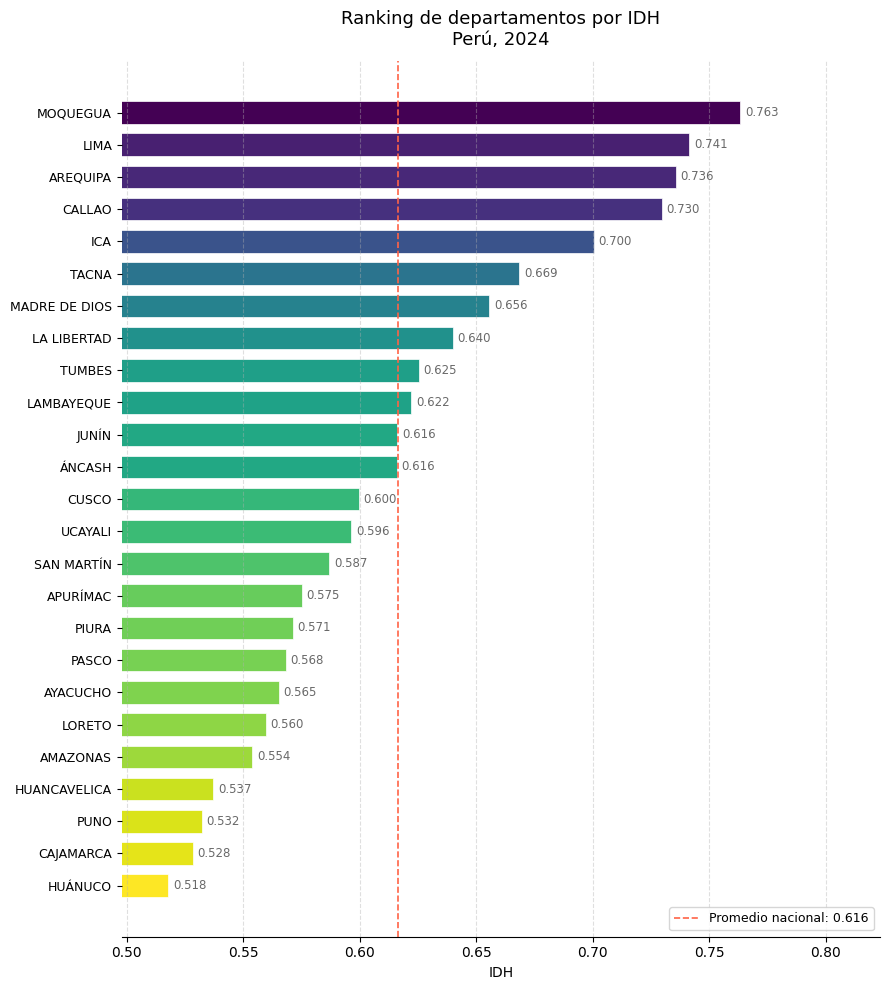

In [ ]:
# Preparar datos
df_rank = df_idh_dpto[["departamento", "idh_2024"]].copy()
df_rank = df_rank[df_rank["departamento"].str.upper() != "PERÚ"]
df_rank = df_rank.dropna(subset=["idh_2024"])
df_rank = df_rank.sort_values("idh_2024", ascending=True).reset_index(drop=True)

norm = plt.Normalize(df_rank["idh_2024"].min(), df_rank["idh_2024"].max())
colores = cm.viridis_r(norm(df_rank["idh_2024"].values))

fig, ax = plt.subplots(figsize=(9, 10))

bars = ax.barh(
    df_rank["departamento"],
    df_rank["idh_2024"],
    color=colores,
    edgecolor="white",
    linewidth=0.5,
    height=0.7
)

# Etiqueta con el valor al final de cada barra
for bar, val in zip(bars, df_rank["idh_2024"]):
    ax.text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center", fontsize=8.5,
        color="dimgray"
    )

# Línea del promedio nacional
promedio = df_rank["idh_2024"].mean()
ax.axvline(promedio, color="tomato", linestyle="--", linewidth=1.2, label=f"Promedio nacional: {promedio:.3f}")

ax.set_title("Ranking de departamentos por IDH\nPerú, 2024", fontsize=13, pad=12)
ax.set_xlabel("IDH", fontsize=10)
ax.set_xlim(df_rank["idh_2024"].min() - 0.02, df_rank["idh_2024"].max() + 0.06)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()

## 5.2. Mapa coroplético

In [ ]:
zip_url = "https://raw.githubusercontent.com/LuisEduardoValverdeRamos/data_class/af0cac5331b44a71fd481c156f02bb40a3aa7809/Provincia_INEI_2017.zip"

zip_path = "Provincia_INEI_2017.zip"

r = requests.get(zip_url) # definimos la ruta para descargar el archivo
r.raise_for_status()
with open(zip_path, "wb") as f:
    f.write(r.content)

zip_path

'Provincia_INEI_2017.zip'

In [ ]:
out_dir = "Provincia_INEI_2017"
os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(out_dir)

# Ver qué archivos hay dentro
for root, _, files in os.walk(out_dir):
    for f in files[:50]:
        print(os.path.join(root, f))

Provincia_INEI_2017/Provincia_INEI_2017.prj
Provincia_INEI_2017/Provincia_INEI_2017.qmd
Provincia_INEI_2017/Provincia_INEI_2017.shx
Provincia_INEI_2017/Provincia_INEI_2017.cpg
Provincia_INEI_2017/Provincia_INEI_2017.dbf
Provincia_INEI_2017/Provincia_INEI_2017.shp


In [ ]:
shp_path = None
for root, _, files in os.walk(out_dir):
    for f in files:
        if f.lower().endswith(".shp"):
            shp_path = os.path.join(root, f)
            break
    if shp_path:
        break

shp_path

'Provincia_INEI_2017/Provincia_INEI_2017.shp'

In [ ]:
gdf_prov = gpd.read_file(shp_path)

gdf_prov.head(), gdf_prov.crs

(   fid  objectid   nombdep idprov ccpp ccdd    nombprov  \
 0  1.0        38  AREQUIPA   0404   04   04    CASTILLA   
 1  2.0        39  AREQUIPA   0405   05   04    CAYLLOMA   
 2  3.0        40  AREQUIPA   0406   06   04  CONDESUYOS   
 3  4.0        41  AREQUIPA   0407   07   04       ISLAY   
 4  5.0        42  AREQUIPA   0408   08   04    LA UNION   
 
                       fuente tematica  id_geograf  \
 0  INEI - CPV2017 RESULTADOS      T10     3040400   
 1  INEI - CPV2017 RESULTADOS      T10     3040500   
 2  INEI - CPV2017 RESULTADOS      T10     3040600   
 3  INEI - CPV2017 RESULTADOS      T10     3040700   
 4  INEI - CPV2017 RESULTADOS      T10     3040800   
 
                                             geometry  
 0  POLYGON ((-71.94412 -14.87577, -71.94318 -14.8...  
 1  POLYGON ((-71.86875 -14.83205, -71.86898 -14.8...  
 2  POLYGON ((-71.98109 -14.64062, -71.98093 -14.6...  
 3  POLYGON ((-71.86948 -16.78479, -71.86951 -16.7...  
 4  POLYGON ((-72.72543 -14.6462

In [ ]:
# Nos quedamos con el IDH
df_idh_mapa = df_idh_dpto[["ubigeo", "departamento", "idh_2020","idh_2021","idh_2022","idh_2023","idh_2024"]].copy()

# El ubigeo departamental tiene 6 dígitos (ej: 010000 = Amazonas)
# Solo necesitamos los 2 primeros para mergear con ccdd del shapefile
df_idh_mapa["ccdd"] = df_idh_mapa["ubigeo"].astype(str).str.zfill(6).str[:2]

print("IDH preparado para merge:")
print(df_idh_mapa.head())

IDH preparado para merge:
   ubigeo departamento  idh_2020  idh_2021  idh_2022  idh_2023  idh_2024 ccdd
0  010000     AMAZONAS  0.529307  0.532614  0.553299  0.555334  0.554043   01
1  020000       ÁNCASH  0.549585  0.564014  0.605702  0.613576  0.615979   02
2  030000     APURÍMAC  0.506995  0.517596  0.563530  0.579678  0.575198   03
3  040000     AREQUIPA  0.696956  0.708061  0.731522  0.724687  0.735687   04
4  050000     AYACUCHO  0.523190  0.518298  0.558929  0.567342  0.565230   05


In [ ]:
# Merge shapefile + IDH
gdf = gdf_prov.copy()

# ccdd del shapefile también son 2 dígitos → asegurar formato
gdf["ccdd_str"] = gdf["ccdd"].astype(str).str.zfill(2)

# Merge a nivel departamental (todas las provincias del dpto reciben el mismo IDH)
gdf_merged = gdf.merge(
    df_idh_mapa[["ccdd", "departamento", "idh_2020","idh_2021","idh_2022","idh_2023","idh_2024"]],
    left_on="ccdd_str",
    right_on="ccdd",
    how="left"
)

# Chequeo de match
n_total = len(gdf_merged)
n_match = gdf_merged["idh_2023"].notna().sum()
print(f"Matched: {n_match}/{n_total} provincias ({n_match/n_total:.1%})")

Matched: 196/196 provincias (100.0%)


**Evolución del IDH provincial en el Perú, 2020–2024**

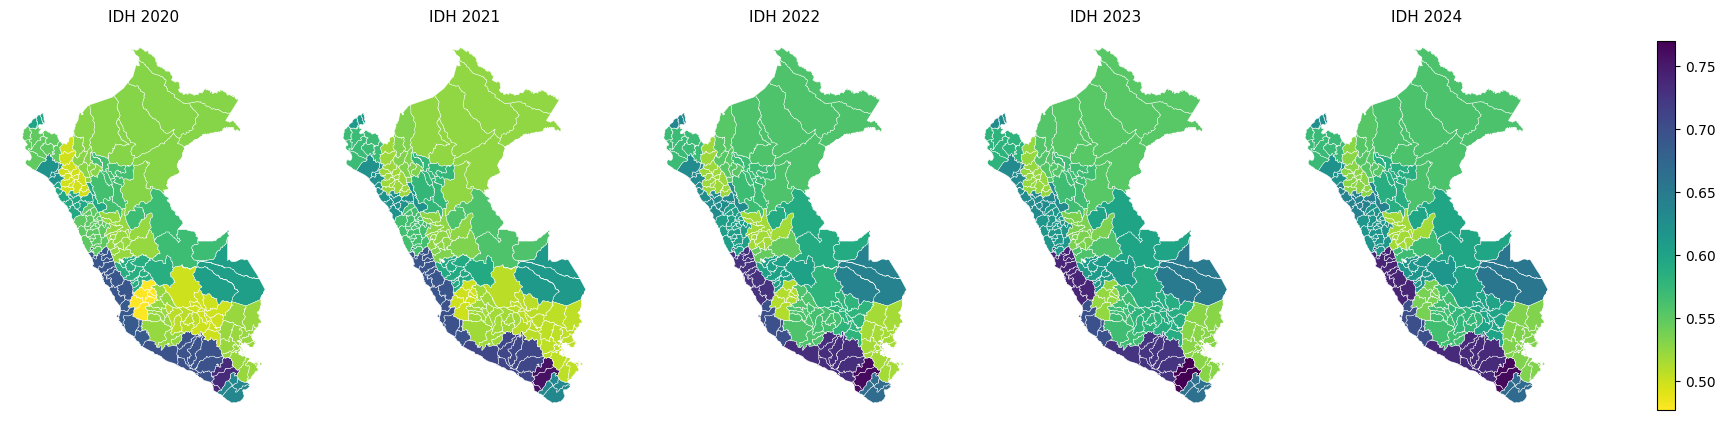

In [ ]:

años = list(range(2020, 2025))  # 2020 al 2024

fig, axes = plt.subplots(1, 5, figsize=(25, 8))  # 1 fila × 5 columnas
axes = axes.flatten()  # convertir matriz a lista para iterar fácil

# Misma escala para todos los mapas → comparación válida
vmin = min(gdf_merged[f"idh_{a}"].min() for a in años)
vmax = max(gdf_merged[f"idh_{a}"].max() for a in años)

for ax, año in zip(axes, años):
    gdf_merged.plot(
        column=f"idh_{año}",
        cmap="viridis_r",
        linewidth=0.3,
        edgecolor="white",
        legend=False,
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Sin datos"}
    )
    ax.set_title(f"IDH {año}", fontsize=11)
    ax.set_axis_off()

# Barra de color compartida para todos
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation="vertical", shrink=0.6)

#fig.suptitle("Evolución del IDH provincial en el Perú, 2020–2024", fontsize=14, y=0.98)
plt.show()

## 5.3. Línea de tendencia

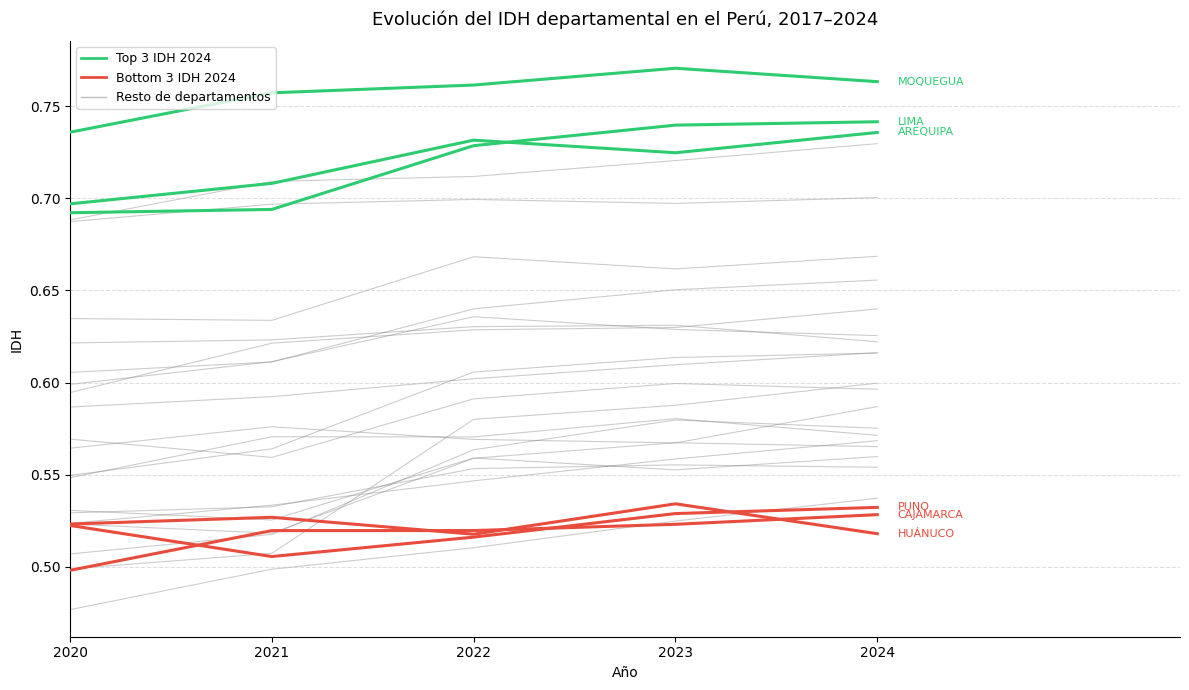

In [ ]:
años = list(range(2020, 2025))

# Preparamos datos en formato largo desde df_idh_dpto
cols_idh = [f"idh_{a}" for a in años]
df_plot = df_idh_dpto[["departamento"] + cols_idh].copy()

# Excluimps fila PERÚ total si existe
df_plot = df_plot[df_plot["departamento"].str.upper() != "PERÚ"].reset_index(drop=True)

# Identificamos extremos para destacarlos
idh_2024 = df_plot.set_index("departamento")["idh_2024"]
top3 = idh_2024.nlargest(3).index.tolist()
bot3 = idh_2024.nsmallest(3).index.tolist()
destacados = top3 + bot3

fig, ax = plt.subplots(figsize=(12, 7))

for _, row in df_plot.iterrows():
    dpto = row["departamento"]
    valores = row[cols_idh].values

    if dpto in top3:
        ax.plot(años, valores, color="#2ecc71", linewidth=2.2, zorder=3)
        ax.text(2024.1, valores[-1], dpto, fontsize=8, color="#2ecc71", va="center")
    elif dpto in bot3:
        ax.plot(años, valores, color="#e74c3c", linewidth=2.2, zorder=3)
        ax.text(2024.1, valores[-1], dpto, fontsize=8, color="#e74c3c", va="center")
    else:
        ax.plot(años, valores, color="gray", linewidth=0.8, alpha=0.4, zorder=1)

# Leyenda manual

leyenda = [
    Line2D([0], [0], color="#2ecc71", linewidth=2, label="Top 3 IDH 2024"),
    Line2D([0], [0], color="#e74c3c", linewidth=2, label="Bottom 3 IDH 2024"),
    Line2D([0], [0], color="gray",    linewidth=1, alpha=0.5, label="Resto de departamentos"),
]
ax.legend(handles=leyenda, fontsize=9, loc="upper left")

ax.set_title("Evolución del IDH departamental en el Perú, 2017–2024", fontsize=13, pad=12)
ax.set_xlabel("Año", fontsize=10)
ax.set_ylabel("IDH", fontsize=10)
ax.set_xticks(años)
ax.set_xlim(2020, 2025.5)   # espacio para las etiquetas
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()